In [1]:
import matplotlib.pyplot as plt
import shapely
import geopandas as gpd
import pandas as pd
from pathlib import Path
from validation import build_trip_geodataframe

SYNTHGEN_DIR="run/atlas_large"
ATLAS_DIR="run/output_500"
INRIX_DIR="/home/isalvador/git/ssmtg/data/inrix_202505"
DATA_DIR="synth_data"

network = gpd.read_file(f"{DATA_DIR}/chicago_osm.shp")
vehicle_highway_types = [
    'motorway', 'motorway_link',
    'trunk', 'trunk_link',
    'primary', 'primary_link',
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'unclassified',
    'residential',
    'living_street',
    'service',
    'busway',
]
network_vehicle = network[network['highway'].isin(vehicle_highway_types)]

filtered_network = gpd.read_file("validation/filtered_network.shp")
filtered_trips = pd.read_parquet("validation/filtered_trips.parquet")

agent_trips = pd.read_csv(f"{SYNTHGEN_DIR}/trips.csv")
agents_simulated = build_trip_geodataframe(ATLAS_DIR, pattern="path_agent_*.html")
synth_path = Path(SYNTHGEN_DIR)

zones = gpd.read_file(synth_path/"zones.shp")
boundary = gpd.read_file(synth_path/"clipping_area.shp")
cbd = gpd.read_file("/home/isalvador/git/ATLAS/synthgen/synth_data/Central_Business_District_20260706/geo_export_2d9a3bb5-e398-41aa-8645-401077366625.shp")

In [227]:
filtered_trips.trip_id.nunique()

1645560

In [220]:
import momepy

G = momepy.gdf_to_nx(network_vehicle, multigraph=False)

/home/isalvador/git/ATLAS/venv/lib/python3.12/site-packages/momepy/utils.py:287: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


In [226]:
import numpy as np
import networkx as nx

def graph_stats(G, expensive=False):
    directed = G.is_directed()
    UG = G.to_undirected() if directed else G
    deg = np.array([d for _, d in G.degree()])

    print(f"type          : {type(G).__name__} ({'directed' if directed else 'undirected'})")
    print(f"nodes / edges : {G.number_of_nodes():,} / {G.number_of_edges():,}")
    print(f"density       : {nx.density(G):.6f}")
    print(f"degree        : mean {deg.mean():.2f}  min {deg.min()}  max {deg.max()}")
    print(f"self-loops    : {nx.number_of_selfloops(G):,}")
    print(f"isolates      : {len(list(nx.isolates(G))):,}")

    comps = list(nx.connected_components(UG))
    sizes = sorted((len(c) for c in comps), reverse=True)
    print(f"components    : {len(comps):,}  (largest {sizes[0]:,} = "
          f"{sizes[0]/G.number_of_nodes():.1%})")
    if directed:
        print(f"strongly conn : {nx.number_strongly_connected_components(G):,}")

    # edge attribute summary — road nets usually carry length/weight
    for attr in ("length", "weight", "travel_time"):
        vals = [d[attr] for *_, d in G.edges(data=True) if attr in d]
        if vals:
            v = np.array(vals, dtype=float)
            print(f"{attr:<14}: sum {v.sum():,.0f}  mean {v.mean():.1f}  "
                  f"median {np.median(v):.1f}")

    if expensive:
        Gc = UG.subgraph(max(comps, key=len)).copy()
        print(f"avg shortest path (LCC): {nx.average_shortest_path_length(Gc):.2f}")
        print(f"diameter (LCC)         : {nx.diameter(Gc)}")

graph_stats(G)

type          : Graph (undirected)
nodes / edges : 123,790 / 91,396
density       : 0.000012
degree        : mean 1.48  min 1  max 10
self-loops    : 614
isolates      : 0
components    : 38,262  (largest 31,479 = 25.4%)


In [2]:
# Get all PUMA zones that do not intersect cbd and not in the lake
target_zones = zones[
    (zones.GEOID10!="17035212") &
    (~zones.intersects(cbd.geometry.iloc[0]))
]

# Get all trajectories that occur from target zone to CBD
target_zone_id = "1703504"
target_zone_geometry = target_zones[target_zones.GEOID10==target_zone_id].geometry.iloc[0]

od_list = (
    filtered_trips
    .sort_values(["trip_id", "traj_idx", "path_idx"])
    .groupby(["trip_id", "traj_idx"])
    .agg(
        origin=("way_id", "first"),
        destination=("way_id", "last"),
        trip_start_utc_ts=("trip_start_utc_ts", "first"),
        trip_end_utc_ts=("trip_end_utc_ts", "first"),
        n_links=("way_id", "count"))
    .reset_index()
)

# keep only the longest traj_idx per trip_id, drop the rest
od_list = (
    od_list
    .sort_values("n_links", ascending=False)
    .drop_duplicates(subset="trip_id", keep="first")
    .reset_index(drop=True)
)

In [3]:
import pandas as pd

# ============================================================
# Precompute the one thing that's constant across all zones: CBD links
# ============================================================
destination_links = filtered_network[filtered_network.intersects(cbd.geometry.iloc[0])].osm_id.unique()

# ============================================================
# Function: count trips from a given zone -> CBD
# ============================================================
def count_trips_to_cbd(zone_geometry, od_list, filtered_network, destination_links):
    origin_links = filtered_network[filtered_network.intersects(zone_geometry)].osm_id.unique()

    matches = od_list[
        (od_list.origin.isin(origin_links)) &
        (od_list.destination.isin(destination_links))
    ]
    return len(matches), matches

# ============================================================
# Loop over every target zone (excluding the CBD zone itself, already excluded in target_zones)
# ============================================================
results = []

for _, zone_row in target_zones.iterrows():
    geoid = zone_row["GEOID10"]
    geometry = zone_row["geometry"]

    n_trips, _ = count_trips_to_cbd(geometry, od_list, filtered_network, destination_links)
    results.append({"GEOID10": geoid, "n_trips": n_trips})

zone_trip_counts = pd.DataFrame(results).sort_values("n_trips", ascending=False).reset_index(drop=True)

print(zone_trip_counts.head(10))

top_zone_id = zone_trip_counts.iloc[0]["GEOID10"]
top_zone_count = zone_trip_counts.iloc[0]["n_trips"]
print(f"\nZone with most trips to CBD: {top_zone_id} ({top_zone_count} trips)")

   GEOID10  n_trips
0  1703522    14710
1  1703504     8708
2  1703502     7356
3  1703521     7186
4  1703408     4190
5  1703523     3570
6  1703422     1850
7  1703529     1786
8  1703526     1560
9  1703520      642

Zone with most trips to CBD: 1703522 (14710 trips)


In [390]:
# residential to cbd
origin_zone = "1703524"
destination_zone = "1703520"

# # cbd to residential
# origin_zone = "1703524"
# destination_zone = "1703527"

# # cbd to residential



# origin_zone="1703523"
# zone_center_geometry = zones[zones.GEOID10.isin(["1703524", "1703525"])].geometry.union_all()

origin_geometry = zones[zones.GEOID10==origin_zone].geometry.iloc[0]
# origin_geometry = zone_center_geometry

destination_geometry = zones[zones.GEOID10==destination_zone].geometry.iloc[0]
# destination_geometry = zone_center_geometry

# get all osm_ids in target zone and CBD
origin_links =       filtered_network[filtered_network.within(origin_geometry)].osm_id.unique()
destination_links =  filtered_network[filtered_network.within(destination_geometry)].osm_id.unique()

target_od_trips = od_list[
    (od_list.origin.isin(origin_links)) &
    (od_list.destination.isin(destination_links))
]

target_trajectories = filtered_trips.merge(
    target_od_trips[["trip_id", "traj_idx"]],
    on=["trip_id", "traj_idx"],
    how="inner"
)

print(target_trajectories.shape)

(3088, 9)


In [391]:
from shapely.ops import unary_union

def set_bounds_from_geometries(ax, *geometries, padding_pct=0.05):
    """
    Set axis limits to the bounding box of all provided geometries.

    Parameters
    ----------
    ax           : matplotlib Axes
    *geometries  : any number of Shapely geometry objects
    padding_pct  : fractional padding around the bounding box (default 5%)
    """
    combined = unary_union(list(geometries))
    minx, miny, maxx, maxy = combined.bounds

    x_pad = (maxx - minx) * padding_pct
    y_pad = (maxy - miny) * padding_pct

    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)

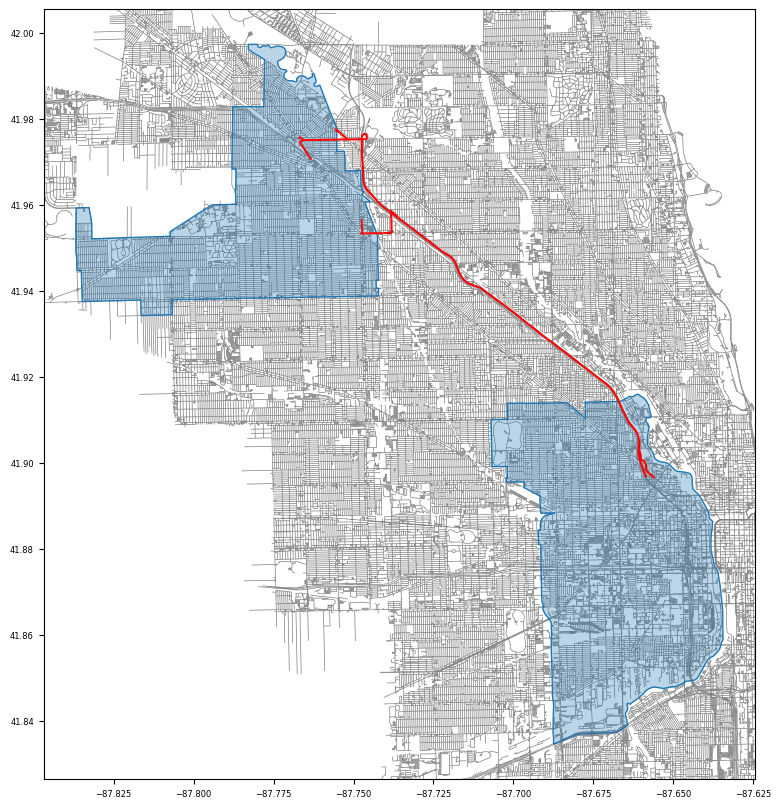

In [392]:
import matplotlib.pyplot as plt
from shapely.plotting import plot_polygon

fig, ax = plt.subplots(figsize=(10,10))

plot_polygon(origin_geometry, ax=ax, add_points=False)
plot_polygon(destination_geometry, ax=ax, add_points=False)

# agents_simulated.plot(ax=ax, zorder=-1, color="green", linewidth=0.1)
network_vehicle.plot(color="gray", zorder=-5, ax=ax, linewidth=0.5)
network_vehicle[network_vehicle.osm_id.isin(target_trajectories.way_id)].plot(ax=ax, color="red")

set_bounds_from_geometries(ax, origin_geometry, destination_geometry)

# AURORA

In [393]:
import geopandas as gpd
import shapely


def add_origin_destination(gdf, line_col="geometry", crs=None):
    """
    Return a copy of gdf with two extra geometry columns:
    'origin' (first point of each line) and 'destination' (last point).
    The original LineString column stays active.
    """
    crs = crs or gdf.crs

    out = gdf.copy()
    out["origin"] = gpd.GeoSeries(
        shapely.get_point(out[line_col].values, 0), crs=crs
    )
    out["destination"] = gpd.GeoSeries(
        shapely.get_point(out[line_col].values, -1), crs=crs
    )

    out = gpd.GeoDataFrame(out, geometry=line_col, crs=crs)
    return out


# usage
agents_simulated_ods = add_origin_destination(agents_simulated)

In [380]:
target_link_counts = target_trajectories.groupby("way_id")["trip_id"].count().rename("total")
traffic_links = filtered_network[filtered_network.osm_id.isin(target_link_counts.index)].copy()

traffic_links = traffic_links.merge(target_link_counts, left_on="osm_id", right_on="way_id")

In [381]:
traffic_links["weight"] = traffic_links["total"] / traffic_links["total"].max()

base = 0.1
scale = 12.0
traffic_links["weight"] = (traffic_links["weight"] + base) * scale

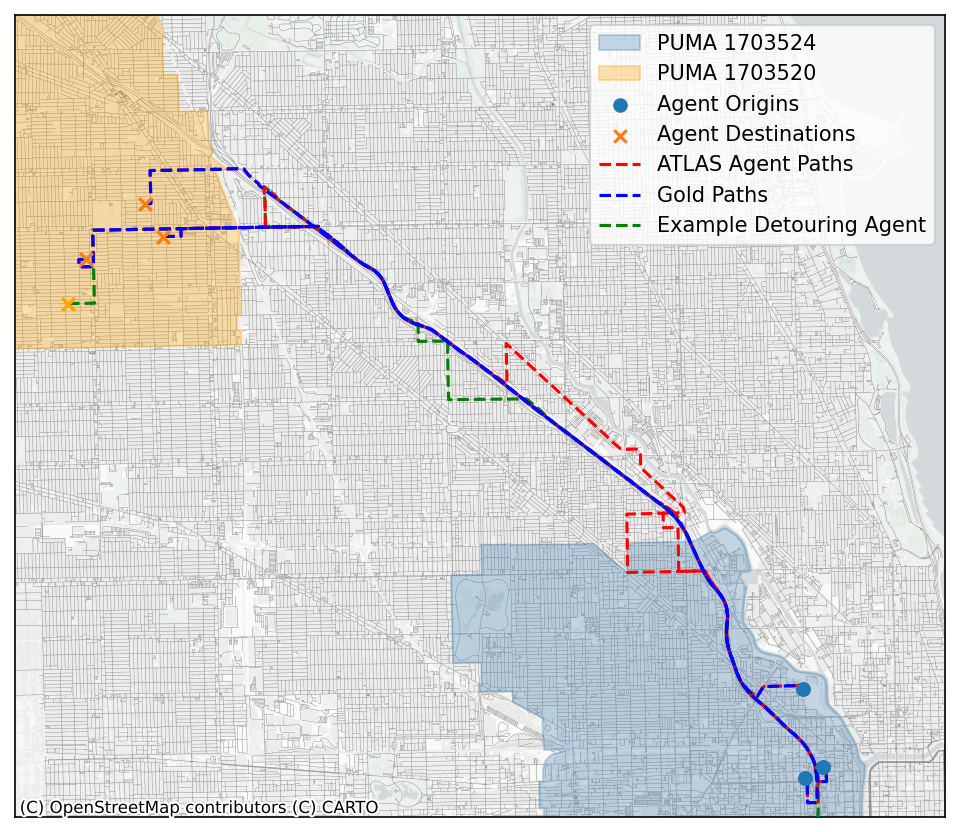

In [420]:
import matplotlib.pyplot as plt
from shapely.plotting import plot_polygon

fig, ax = plt.subplots(figsize=(8,8), dpi=150)

plot_polygon(origin_geometry, ax=ax, add_points=False, color="steelblue", alpha=0.3, label=f"PUMA {origin_zone}")
plot_polygon(destination_geometry, ax=ax, add_points=False, color="orange", alpha=0.3, label=f"PUMA {destination_zone}")



# target_agent_trips = agents_simulated_ods[agents_simulated_ods.agent_id.isin(["agent_0616"])]  # [
#     agents_simulated_ods.set_geometry("origin").within(origin_geometry) &
#     agents_simulated_ods.set_geometry("destination").within(destination_geometry)
# ]


target_agent_trips = agents_simulated_ods[
    (agents_simulated_ods.set_geometry("origin").within(origin_geometry) &
    agents_simulated_ods.set_geometry("destination").within(destination_geometry)) 
]

plotting_agent = agents_simulated_ods[
    (agents_simulated_ods.agent_id=="agent_0616") &
    (agents_simulated_ods.trip_num==4)
]

target_agent_trips = target_agent_trips[target_agent_trips.agent_id.isin([
    "agent_0709", "agent_0063", "agent_0708"
])]

target_agent_trips.set_geometry("origin").plot(ax=ax, marker="o", zorder=100, label="Agent Origins")
target_agent_trips.set_geometry("destination").plot(ax=ax, marker="x", zorder=100, label="Agent Destinations")

target_agent_trips[target_agent_trips.path_type=="agent"].plot(ax=ax, linestyle='--', color="red", zorder=20, label="ATLAS Agent Paths")
target_agent_trips[target_agent_trips.path_type=="gold"].plot(ax=ax, linestyle='--', color="blue", zorder=20, label="Gold Paths")


plotting_agent[plotting_agent.path_type=="agent"].plot(ax=ax, linestyle='--', color="green", zorder=19, label="Example Detouring Agent")
plotting_agent.set_geometry("destination").plot(ax=ax, marker="x", zorder=100, color="orange")
# plotting_agent[plotting_agent.path_type=="gold"].plot(ax=ax, linestyle=':', color="blue", zorder=20, label="Gold Paths")

network_vehicle.plot(color="gray", zorder=-5, ax=ax, linewidth=0.2)

set_bounds_from_geometries(ax, origin_geometry, destination_geometry)

plt.ylim(41.88, 41.98)
plt.xlim(-87.78)

plt.xticks([])
plt.yticks([])


import contextily as ctx
ctx.add_basemap(ax, crs = target_agent_trips.crs, source=ctx.providers.CartoDB.PositronNoLabels, zoom=15, zorder=-100)

plt.legend()
plt.legend(fontsize=10)

plt.show()

In [399]:
target_agent_trips.agent_id.unique()

array(['agent_0029', 'agent_0055', 'agent_0063', 'agent_0108',
       'agent_0111', 'agent_0141', 'agent_0149', 'agent_0163',
       'agent_0169', 'agent_0177', 'agent_0187', 'agent_0189',
       'agent_0261', 'agent_0276', 'agent_0302', 'agent_0324',
       'agent_0347', 'agent_0355', 'agent_0371', 'agent_0380',
       'agent_0392', 'agent_0409', 'agent_0411', 'agent_0425',
       'agent_0439', 'agent_0445', 'agent_0456', 'agent_0519',
       'agent_0537', 'agent_0599', 'agent_0602', 'agent_0607',
       'agent_0620', 'agent_0650', 'agent_0668', 'agent_0675',
       'agent_0679', 'agent_0708', 'agent_0709', 'agent_0719',
       'agent_0736'], dtype=object)

In [397]:
target_agent_trips.drop(["origin", "destination"], axis=1).to_file("test/test_trj.shp")

/tmp/ipykernel_1354364/1786647726.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  target_agent_trips.drop(["origin", "destination"], axis=1).to_file("test/test_trj.shp")
/home/isalvador/git/ATLAS/venv/lib/python3.12/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'gold_pts_total' to 'gold_pts_t'
  ogr_write(
/home/isalvador/git/ATLAS/venv/lib/python3.12/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'gold_maneuvers' to 'gold_maneu'
  ogr_write(
/home/isalvador/git/ATLAS/venv/lib/python3.12/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'agent_steps_total' to 'agent_step'
  ogr_write(
/home/isalvador/git/ATLAS/venv/lib/python3.12/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'source_file' to 'source_fil'
  ogr_write(


# Departure Times

In [39]:
trip_starts = filtered_trips.drop_duplicates(subset="trip_id")[["trip_id", "trip_start_utc_ts"]]

In [70]:
# 1. Make sure the column is tz-aware UTC
trip_starts['ts'] = pd.to_datetime(trip_starts['trip_start_utc_ts'], unit="ms", utc=True)   # works whether it's naive-UTC or already aware

# 2. Convert to the local zone
trip_starts['ts_local'] = trip_starts['ts'].dt.tz_convert('America/Chicago')

# 3. Seconds since local midnight
midnight = trip_starts['ts_local'].dt.normalize()        # DST-aware local midnight
trip_starts['secs_since_midnight'] = (trip_starts['ts_local'] - midnight).dt.total_seconds()

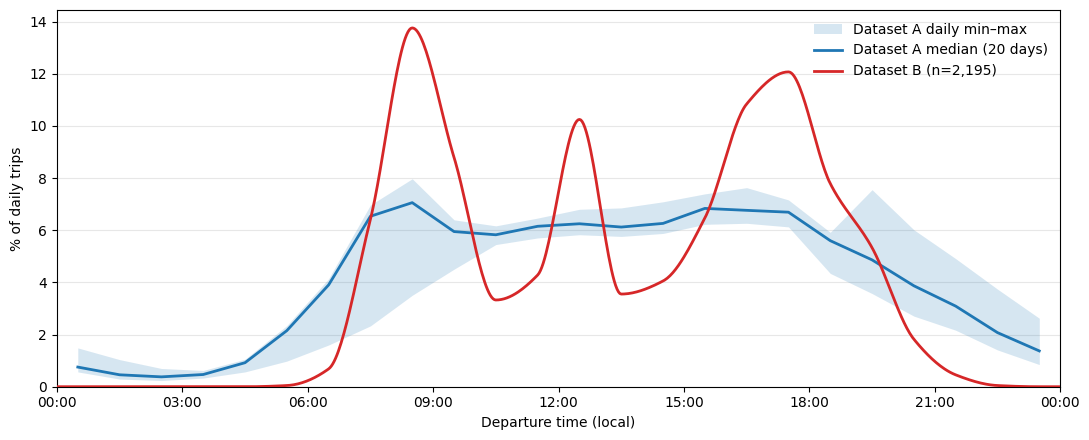

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.interpolate import PchipInterpolator

TZ = 'America/Chicago'
BIN = 1.0
NORM = True
WEEKDAYS_ONLY = True
SMOOTH_B = True

bins = np.arange(0, 24 + BIN, BIN)
centers = bins[:-1] + BIN / 2

def to_hours(s):
    x = np.asarray(s, dtype=float)
    return (x[~np.isnan(x)] % 86400) / 3600

def daily_profiles(ts_local, bins, normalize=True):
    t = pd.DatetimeIndex(pd.Series(ts_local).dropna())
    h = t.hour + t.minute / 60 + t.second / 3600
    idx = pd.cut(h, bins=bins, right=False, labels=False)
    tab = (pd.crosstab(t.normalize(), idx)
             .reindex(columns=range(len(bins) - 1), fill_value=0))
    return tab.div(tab.sum(axis=1), axis=0) * 100 if normalize else tab

def smooth_cyclic(x, y, n=721):
    xt = np.concatenate([x - 24, x, x + 24])
    yt = np.tile(y, 3)
    g = np.linspace(0, 24, n)
    return g, np.clip(PchipInterpolator(xt, yt)(g), 0, None)

# --- Dataset A ---
t_local = (pd.to_datetime(trip_starts['trip_start_utc_ts'], unit='ms', utc=True)
             .dt.tz_convert(TZ))
P = daily_profiles(t_local, bins, normalize=NORM)
if WEEKDAYS_ONLY:
    P = P[P.index.dayofweek < 5]
A = P.values

med = np.median(A, axis=0)
lo, hi = A.min(axis=0), A.max(axis=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
C = '#1f77b4'

ax.fill_between(centers, lo, hi, color=C, alpha=0.18, lw=0, zorder=2,
                label='Dataset A daily min–max')
ax.plot(centers, med, color=C, lw=2, zorder=4,
        label=f'Dataset A median ({len(A)} days)')

# --- Dataset B ---
xb = to_hours(agent_trips['departure_sec'])
cb, _ = np.histogram(xb, bins=bins)
yb = 100 * cb / cb.sum() if NORM else cb

if SMOOTH_B:
    gb, sb = smooth_cyclic(centers, yb)
    ax.plot(gb, sb, color='#d62728', lw=2, zorder=5,
            label=f'Dataset B (n={len(xb):,})')
else:
    ax.plot(centers, yb, color='#d62728', lw=2, zorder=5,
            label=f'Dataset B (n={len(xb):,})')

ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_major_formatter(FuncFormatter(lambda h, _: f'{int(h) % 24:02d}:00'))
ax.set_xlabel('Departure time (local)')
ax.set_ylabel('% of daily trips' if NORM else 'Trips per day')
ax.legend(frameon=False)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()

## 1. Circuity (Detour Ratio, vs. shortest path)

Ratio of the actual (synthetic or historical) trajectory length to the network **shortest-path** length between the same origin and destination:

$$
C = \frac{L_{traj}}{L_{sp}}
$$

where $L_{traj}$ is the length of the trajectory being evaluated and $L_{sp}$ is the shortest-path distance on the road network between its endpoints.

**Interpretation:**
- $C = 1$: the trajectory *is* the shortest path — no detour at all.
- $C > 1$: the trajectory deviates from the optimum; e.g. $C = 1.15$ means a 15% longer route than necessary.
- For your project: if synthetic trajectories cluster at $C \approx 1$ while historical data has a spread (typically $1.05$–$1.3$+ with a long right tail), that's a strong signal the generator is producing unrealistically optimal paths. A good synthetic generator should reproduce the **shape of the historical $C$ distribution**, not just its mean.

*(Note: in some transportation literature — e.g. Giacomin & Levinson (2015) — "circuity" is defined instead as network shortest-path distance over **Euclidean** distance between two points, i.e. $C_{net} = L_{sp}/L_{euclidean}$. That version measures how indirect the *network itself* is, independent of any specific trip. To avoid ambiguity in your write-up, it's worth explicitly stating you're using "detour ratio relative to shortest path" rather than the network-circuity definition — or just relabel this as "detour ratio" in your text.)*

---

## Agent Circuities

In [285]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

CRS_M = 26971  # NAD83 / Illinois East, metres

paths_m = agents_simulated.to_crs(epsg=CRS_M)

agent_paths = (paths_m[paths_m.path_type == "agent"]
               .rename_geometry("agent_geometry")[["agent_id", "trip_num", "agent_geometry"]])
gold_paths  = (paths_m[paths_m.path_type == "gold"]
               .rename_geometry("gold_geometry")[["agent_id", "trip_num", "gold_geometry"]])

cmp = agent_paths.merge(gold_paths, on=["agent_id", "trip_num"],
                        how="outer", indicator=True, validate="one_to_one")
print(cmp["_merge"].value_counts())          # audit before dropping
cmp = cmp[cmp["_merge"] == "both"].drop(columns="_merge").reset_index(drop=True)

# force real GeoSeries so .length is guaranteed to exist
ageo = gpd.GeoSeries(cmp["agent_geometry"], crs=CRS_M)
ggeo = gpd.GeoSeries(cmp["gold_geometry"],  crs=CRS_M)

# validate the trip_num pairing
a0 = gpd.GeoSeries([Point(g.coords[0])  for g in ageo], crs=CRS_M)
a1 = gpd.GeoSeries([Point(g.coords[-1]) for g in ageo], crs=CRS_M)
g0 = gpd.GeoSeries([Point(g.coords[0])  for g in ggeo], crs=CRS_M)
g1 = gpd.GeoSeries([Point(g.coords[-1]) for g in ggeo], crs=CRS_M)
print("start mismatches:", (a0.distance(g0) > 1.0).sum())
print("end mismatches:  ", (a1.distance(g1) > 1.0).sum())

cmp["agent_dist_m"] = ageo.length
cmp["gold_dist_m"]  = ggeo.length
cmp["od_dist_m"]    = a0.distance(a1)

cmp["detour_ratio"]    = cmp["agent_dist_m"] / cmp["gold_dist_m"].replace(0, pd.NA)
cmp["circuity_agent"]  = cmp["agent_dist_m"] / cmp["od_dist_m"].replace(0, pd.NA)
cmp["circuity_gold"]   = cmp["gold_dist_m"]  / cmp["od_dist_m"].replace(0, pd.NA)

_merge
both          1716
left_only        0
right_only       0
Name: count, dtype: int64
start mismatches: 12
end mismatches:   77


In [11]:
# convert path geometries to meters and seperate by path type
agents_simulated_m = agents_simulated.to_crs(epsg=26971)
agent_paths = agents_simulated_m.copy()[agents_simulated.path_type=="agent"]
gold_paths  = agents_simulated_m.copy()[agents_simulated.path_type=="gold"]
agent_paths.rename(columns={"geometry":"agent_geometry"}, inplace=True)
gold_paths.rename(columns={"geometry":"gold_geometry"}, inplace=True)

# join agent/gold paths
agent_gold_path_comparison = pd.merge(
    left=agent_paths[["agent_id", "trip_num", "agent_geometry"]],
    right=gold_paths[["agent_id", "trip_num", "gold_geometry"]],
    on=["agent_id", "trip_num"],
    how="inner"
)

# get path lengths
agent_gold_path_comparison["agent_dist_m"] = agent_gold_path_comparison["agent_geometry"].length
agent_gold_path_comparison["gold_dist_m"] = agent_gold_path_comparison["gold_geometry"].length

# calculate circuities
agent_gold_path_comparison["circuity"] = agent_gold_path_comparison.apply(
    lambda row: row.agent_dist_m/row.gold_dist_m, axis=1
)

In [ ]:
agent_gold_path_comparison["agent_idx"] = agent_gold_path_comparison["agent_id"].apply(
    lambda x: int(x.split("_")[-1])
)

In [84]:
agent_trips["trip_num"]=agent_trips["trip_id"]+1
agent_circuity_by_trip = agent_gold_path_comparison.merge(right=agent_trips[["agent_idx", "trip_num", "origin", "destination", "departure_sec"]], on=["agent_idx", "trip_num"])
agent_circuity_by_trip["trip_purpose"] = agent_circuity_by_trip.apply(
    lambda row: row.origin+" to\n"+row.destination, axis=1
)

agent_circuity_by_trip_filtered = agent_circuity_by_trip[agent_circuity_by_trip.circuity >= 1.0]

## Circuity metrics

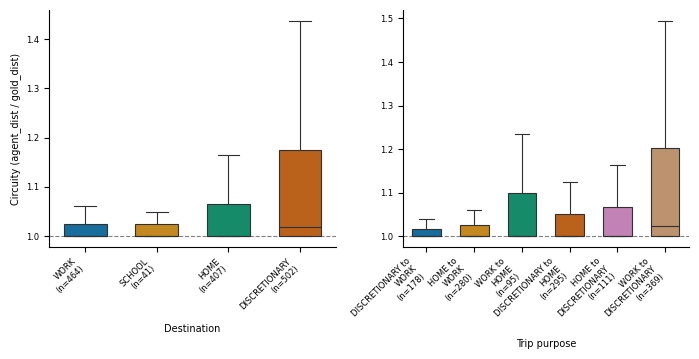

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================
DF          = agent_circuity_by_trip_filtered
VAL_COL     = "circuity"

LEFT_COL    = "destination"
RIGHT_COL   = "trip_purpose"
LEFT_XLAB   = "Destination"
RIGHT_XLAB  = "Trip purpose"
Y_LABEL     = "Circuity (agent_dist / gold_dist)"

LEFT_TOP_N  = None            # None = keep all
RIGHT_TOP_N = 6
RANK_BY     = "count"         # how "top N" is picked: "count" | "median" | "mean" | "max"
ORDER_BY    = "median"        # how kept groups are arranged on the axis
ORDER_ASC   = True

LEFT_FLIERS  = False
RIGHT_FLIERS = False
WHIS        = 1.5             # whisker length in IQR; (5, 95) for percentile whiskers
FLIERSIZE   = 1.5
BOX_WIDTH   = 0.6

REF_LINE    = 1.0             # perfect-match reference; None to hide
SHARE_Y     = False
LEFT_YLAB   = True
RIGHT_YLAB  = False           # ticks still drawn, just no axis label
SHOW_N      = True
PANEL_TAGS  = None # ("a", "b")      # None to hide

PALETTE     = "colorblind"
LINEWIDTH   = 0.8
XROT        = 45

FIGSIZE     = (7.0, 3.6)      # inches, double-column
FONT_SIZE   = 7
# ============================================================

plt.rcParams.update({
    "font.size": FONT_SIZE, "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE - 1, "ytick.labelsize": FONT_SIZE - 1,
    "font.family": "sans-serif", "pdf.fonttype": 42, "ps.fonttype": 42,
})


def _prepare(df, by, top_n):
    """Filter to top_n groups, then return (subset, axis order)."""
    if top_n is not None:
        agg = "size" if RANK_BY == "count" else RANK_BY
        keep = (df.groupby(by)[VAL_COL].agg(agg)
                  .sort_values(ascending=False).head(top_n).index)
        df = df[df[by].isin(keep)]
    order = (df.groupby(by)[VAL_COL].agg(ORDER_BY)
               .sort_values(ascending=ORDER_ASC).index.tolist())
    return df, order


def circuity_box(df, by, ax, xlabel, top_n=None, showfliers=False, ylabel=True):
    sub, order = _prepare(df, by, top_n)

    sns.boxplot(data=sub, x=by, y=VAL_COL, order=order,
                hue=by, hue_order=order, palette=PALETTE, legend=False,
                showfliers=showfliers, fliersize=FLIERSIZE, whis=WHIS,
                width=BOX_WIDTH, linewidth=LINEWIDTH, ax=ax)

    if REF_LINE is not None:
        ax.axhline(REF_LINE, ls="--", lw=0.8, color="grey", zorder=0)

    n = sub.groupby(by)[VAL_COL].size()
    labels = [f"{c}\n(n={n[c]})" if SHOW_N else str(c) for c in order]
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels, rotation=XROT, ha="right" if XROT else "center")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(Y_LABEL if ylabel else "")
    return ax


fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, sharey=SHARE_Y)

circuity_box(DF, LEFT_COL,  axes[0], LEFT_XLAB,
             top_n=LEFT_TOP_N,  showfliers=LEFT_FLIERS,  ylabel=LEFT_YLAB)
circuity_box(DF, RIGHT_COL, axes[1], RIGHT_XLAB,
             top_n=RIGHT_TOP_N, showfliers=RIGHT_FLIERS, ylabel=RIGHT_YLAB)

if PANEL_TAGS:
    for ax, tag in zip(axes, PANEL_TAGS):
        ax.text(-0.02, 1.04, f"({tag})", transform=ax.transAxes,
                fontweight="bold", fontsize=FONT_SIZE + 1, ha="right", va="bottom")

sns.despine(fig=fig)
fig.tight_layout()

# Validation Circuity

In [16]:
"""trip_circuity.py — observed vs. shortest-path length for map-matched trips.
"""

import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import dijkstra


# ----------------------------------------------------------------------
# 1. Routing graph
# ----------------------------------------------------------------------
def build_routing_graph(network, crs, id_col="osm_id", precision=2):
    """
    Project the network, split every way at vertices shared with другой way,
    and return a compact undirected weighted graph.

    Returns dict with:
        A            : scipy CSR adjacency (weights = metres)
        node_coords  : (n_nodes, 2) float array
        way_length   : Series osm_id -> total length (m)
        way_nodes    : DataFrame osm_id -> (first_node, last_node)
        geom_by_id   : Series osm_id -> projected geometry
    """
    net = network[["geometry", id_col]].copy()
    net = net.to_crs(crs)
    net = net.explode(index_parts=False).reset_index(drop=True)
    net = net[net.geometry.geom_type == "LineString"]
    net[id_col] = net[id_col].astype(str)

    geoms = net.geometry.values
    n_lines = len(geoms)

    # --- vertices -> node ids -------------------------------------------------
    coords, line_idx = shapely.get_coordinates(geoms, return_index=True)
    keys = np.round(coords, precision)
    keys[keys == 0] = 0.0                       # kill -0.0 so bytes compare equal
    kv = np.ascontiguousarray(keys).view(
        [("x", keys.dtype), ("y", keys.dtype)]
    ).ravel()
    uniq, first_idx, node_id = np.unique(kv, return_index=True, return_inverse=True)
    node_id = node_id.astype(np.int64)
    node_coords = keys[first_idx]
    counts = np.bincount(node_id, minlength=len(uniq))   # >=2 => junction

    # --- cumulative distance along the coordinate stream ----------------------
    seg = np.zeros(len(coords))
    d = np.linalg.norm(np.diff(coords, axis=0), axis=1)
    seg[1:] = np.where(line_idx[1:] == line_idx[:-1], d, 0.0)
    cum = np.cumsum(seg)        # differences are valid *within* a line

    starts = np.searchsorted(line_idx, np.arange(n_lines), side="left")
    ends = np.searchsorted(line_idx, np.arange(n_lines), side="right")

    # --- split lines into edges ----------------------------------------------
    U, V, W = [], [], []
    way_len = np.zeros(n_lines)
    first_node = np.zeros(n_lines, dtype=np.int64)
    last_node = np.zeros(n_lines, dtype=np.int64)

    for i in range(n_lines):
        s, e = starts[i], ends[i]
        if e - s < 2:
            continue
        nodes = node_id[s:e]
        mask = counts[nodes] >= 2
        mask[0] = mask[-1] = True
        pos = s + np.flatnonzero(mask)

        U.append(node_id[pos[:-1]])
        V.append(node_id[pos[1:]])
        W.append(cum[pos[1:]] - cum[pos[:-1]])

        way_len[i] = cum[e - 1] - cum[s]
        first_node[i] = nodes[0]
        last_node[i] = nodes[-1]

    u = np.concatenate(U); v = np.concatenate(V); w = np.concatenate(W)

    # dedupe parallel edges, keep the shortest
    lo, hi = np.minimum(u, v), np.maximum(u, v)
    ed = (pd.DataFrame({"u": lo, "v": hi, "w": w})
            .groupby(["u", "v"], sort=False)["w"].min().reset_index())
    ed = ed[ed.u != ed.v]

    # compact node ids
    used = np.unique(np.concatenate([ed.u.values, ed.v.values]))
    remap = np.full(len(uniq), -1, dtype=np.int64)
    remap[used] = np.arange(len(used))

    A = coo_matrix(
        (ed.w.values, (remap[ed.u.values], remap[ed.v.values])),
        shape=(len(used), len(used)),
    ).tocsr()

    ways = pd.DataFrame({
        "id": net[id_col].values,
        "length": way_len,
        "first_node": remap[first_node],
        "last_node": remap[last_node],
    })
    way_length = ways.groupby("id")["length"].sum()
    way_nodes = ways.groupby("id").agg(
        first_node=("first_node", "first"), last_node=("last_node", "last")
    )
    geom_by_id = net.drop_duplicates(id_col).set_index(id_col).geometry

    return dict(A=A, node_coords=node_coords[used], way_length=way_length,
                way_nodes=way_nodes, geom_by_id=geom_by_id)


# ----------------------------------------------------------------------
# 2. Trip metrics
# ----------------------------------------------------------------------
def compute_trip_detour_ratios(
    trips, network, crs,
    trip_id_col="trip_id", traj_col="traj_idx", way_col="way_id",
    order_col="path_idx", network_id_col="osm_id",
    keep_longest_traj=True, precision=2, chunk=8, graph=None,
):
    """
    Parameters
    ----------
    trips   : DataFrame, one row per (trip, traj, link) in traversal order
    network : GeoDataFrame of OSM ways
    crs     : projected CRS for lengths, e.g. 26971 (Illinois East, metres)
    graph   : optional pre-built dict from build_routing_graph() to reuse

    Returns
    -------
    DataFrame: trip_id, traj_idx, n_links, trip_length_m,
               shortest_path_m, detour_ratio
    """
    g = graph or build_routing_graph(network, crs, network_id_col, precision)
    A, node_coords = g["A"], g["node_coords"]
    way_length, way_nodes, geom_by_id = g["way_length"], g["way_nodes"], g["geom_by_id"]

    t = trips.copy()
    t[way_col] = t[way_col].astype(str)
    keys = [trip_id_col] + ([traj_col] if traj_col in t.columns else [])
    t = t.sort_values(keys + [order_col])

    # --- observed length ------------------------------------------------------
    t["_len"] = t[way_col].map(way_length)
    obs = t.groupby(keys).agg(
        n_links=(way_col, "size"),
        trip_length_m=("_len", "sum"),
        n_missing=("_len", lambda s: s.isna().sum()),
        first_way=(way_col, "first"),
        last_way=(way_col, "last"),
    ).reset_index()

    if keep_longest_traj and traj_col in t.columns:
        obs = (obs.sort_values("n_links", ascending=False)
                  .drop_duplicates(trip_id_col, keep="first")
                  .sort_values(keys).reset_index(drop=True))

    # --- resolve which end of the terminal ways is O and D --------------------
    seq = t.groupby(keys)[way_col].apply(list)

    def terminal_node(way, neighbour, take_far):
        """Pick the endpoint of `way` furthest from `neighbour` (=true O or D)."""
        if way not in way_nodes.index:
            return -1
        a, b = way_nodes.loc[way, ["first_node", "last_node"]]
        if neighbour is None or neighbour not in geom_by_id.index or a == b:
            return a if take_far else b
        ng = geom_by_id.loc[neighbour]
        pa = shapely.Point(node_coords[a])
        pb = shapely.Point(node_coords[b])
        da, db = ng.distance(pa), ng.distance(pb)
        return a if da >= db else b

    o_nodes, d_nodes = [], []
    for _, row in obs.iterrows():
        ways = seq.loc[tuple(row[k] for k in keys) if len(keys) > 1 else row[keys[0]]]
        o_nodes.append(terminal_node(ways[0], ways[1] if len(ways) > 1 else None, True))
        d_nodes.append(terminal_node(ways[-1], ways[-2] if len(ways) > 1 else None, False))
    obs["_o"], obs["_d"] = o_nodes, d_nodes

    # --- shortest paths, one Dijkstra per unique origin -----------------------
    sp = np.full(len(obs), np.nan)
    valid = (obs._o >= 0) & (obs._d >= 0)
    origins = np.unique(obs.loc[valid, "_o"].values)

    for i in range(0, len(origins), chunk):
        src = origins[i:i + chunk]
        dist = dijkstra(A, directed=False, indices=src)
        pos = {s: k for k, s in enumerate(src)}
        sel = valid & obs._o.isin(src)
        idx = np.flatnonzero(sel.values)
        sp[idx] = [dist[pos[obs._o.values[j]], obs._d.values[j]] for j in idx]

    obs["shortest_path_m"] = np.where(np.isinf(sp), np.nan, sp)
    obs["detour_ratio"] = obs.trip_length_m / obs.shortest_path_m.replace(0, np.nan)

    cols = keys + ["n_links", "trip_length_m", "shortest_path_m",
                   "detour_ratio", "n_missing"]
    return obs[cols]

In [17]:
graph = build_routing_graph(network_vehicle, crs=26971)


trip_sample = filtered_trips[filtered_trips["trip_id"].isin(filtered_trips["trip_id"].drop_duplicates().sample(n=10000, random_state=1))]

sample_trip_circuities = compute_trip_detour_ratios(trip_sample, filtered_network, crs=26971)

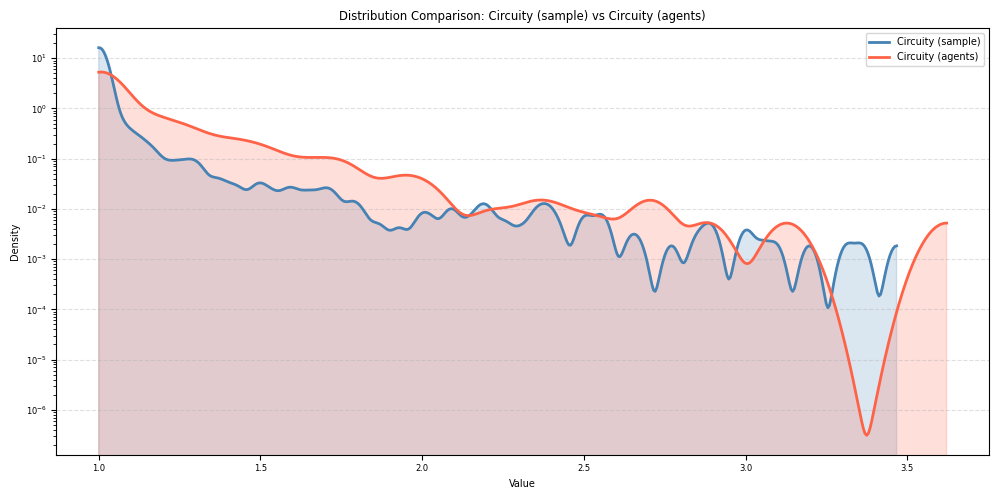

In [314]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde
import numpy as np

def plot_distributions(df1, col1, label1, df2, col2, label2):
    """
    Plot two KDE distributions on the same axis.

    Parameters
    ----------
    df1, df2     : DataFrames
    col1, col2   : column names (strings)
    label1, label2 : legend labels
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    for data, label, color in [
        (df1[col1].dropna(), label1, "steelblue"),
        (df2[col2].dropna(), label2, "tomato"),
    ]:
        kde = gaussian_kde(data)
        x = np.linspace(data.min(), data.max(), 500)
        ax.plot(x, kde(x), linewidth=2, label=label, color=color)
        ax.fill_between(x, kde(x), alpha=0.2, color=color)

    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.set_title(f"Distribution Comparison: {label1} vs {label2}")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.yscale("log")
    plt.tight_layout()
    plt.show()


plot_distributions(
    sample_trip_circuities[sample_trip_circuities.detour_ratio<agent_circuity_by_trip_filtered.circuity.max()],        "detour_ratio",  "Circuity (sample)",
    agent_circuity_by_trip_filtered, "circuity",    "Circuity (agents)",)

In [445]:
import numpy as np, pandas as pd

EDGES = np.array([250, 500, 1000, 2000, 4000, 8000, 16000, 32000, 64000])


def _wq(x, w, q):
    o = np.argsort(x); x, w = x[o], w[o]
    c = np.cumsum(w) / w.sum()
    return x[min(np.searchsorted(c, q), len(x) - 1)]


def _stats(x, w=None, eps=1e-3):
    x = np.asarray(x, float)
    w = np.ones_like(x) if w is None else np.asarray(w, float)
    d = x > 1 + eps
    W = w.sum()
    mean = np.average(x, weights=w)
    exc  = np.average(x[d] - 1, weights=w[d]) if d.any() else np.nan
    rate = w[d].sum() / W
    return {
        "n": len(x),
        "n_detour": len(x) * rate,
        "ess": W ** 2 / (w ** 2).sum(),
        "mean": mean,
        "median": _wq(x, w, 0.50),
        "det_rate": rate,
        "mean_exc_if_det": exc,
        "p90": _wq(x, w, 0.90),
        # diagnostic: residual of  mean - 1 = r*E[x-1|det] + (1-r)*E[x-1|no det]
        "resid": (mean - 1) - rate * (0.0 if np.isnan(exc) else exc),
    }


def circuity_table(agent_df, ref_df, group="destination",
                   a_dist="agent_dist_m", a_ratio="circuity",
                   r_dist="trip_length_m", r_ratio="detour_ratio",
                   edges=EDGES, eps=1e-3, min_n=1, sort_by="mean"):
    a = agent_df[[group, a_dist, a_ratio]].rename(
            columns={a_dist: "dist", a_ratio: "ratio"}).dropna().copy()
    r = ref_df[[r_dist, r_ratio]].rename(
            columns={r_dist: "dist", r_ratio: "ratio"}).dropna().copy()

    a["bin"] = pd.cut(a.dist, edges).astype(object)
    r["bin"] = pd.cut(r.dist, edges).astype(object)
    a, r = a.dropna(subset=["bin"]), r.dropna(subset=["bin"])

    # global standardization: reference reweighted to the full agent length distribution
    wmap = (a.bin.value_counts(normalize=True) / r.bin.value_counts()).dropna().astype(float)
    rw = r.bin.map(wmap).astype(float)
    ok = rw.notna()

    rows = {
        "agent":        _stats(a.ratio, eps=eps),
        "ref":          _stats(r.ratio, eps=eps),
        "ref/standard": _stats(r.ratio[ok], rw[ok], eps=eps),
    }

    dest = {g: _stats(sub.ratio, eps=eps)
            for g, sub in a.groupby(group, observed=True) if len(sub) >= min_n}
    dest = pd.DataFrame.from_dict(dest, orient="index").sort_values(sort_by, ascending=False)

    out = pd.concat([pd.DataFrame.from_dict(rows, orient="index"), dest])
    out.index.name = "group"
    out["n"] = out["n"].astype(int)
    return out[["n", "n_detour", "det_rate", "mean", "median", "mean_exc_if_det", "p90"]]


res = circuity_table(agent_circuity_by_trip_filtered, sample_trip_circuities)

with pd.option_context("display.max_rows", None, "display.width", 200,
                       "display.float_format", "{:.4f}".format):
    print(res)

                  n  n_detour  det_rate   mean  median  mean_exc_if_det    p90
group                                                                         
agent          1414  583.0000    0.4123 1.0995  1.0000           0.2413 1.3190
ref            9660 2646.0000    0.2739 1.0542  1.0000           0.1977 1.0344
ref/standard   9660 4857.7574    0.5029 1.0304  1.0013           0.0603 1.0805
DISCRETIONARY   502  263.0000    0.5239 1.1406  1.0184           0.2684 1.4315
HOME            407  172.0000    0.4226 1.0770  1.0000           0.1821 1.2356
WORK            464  137.0000    0.2953 1.0769  1.0000           0.2605 1.2700
SCHOOL           41   11.0000    0.2683 1.0747  1.0000           0.2785 1.2242


/tmp/ipykernel_1354364/483914867.py:48: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  wmap = (a.bin.value_counts(normalize=True) / r.bin.value_counts()).dropna().astype(float)
/tmp/ipykernel_1354364/483914867.py:48: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  wmap = (a.bin.value_counts(normalize=True) / r.bin.value_counts()).dropna().astype(float)


Diff-RNTraj — the closest match to your setup, road-network-constrained with the JSD-RS road segment metric:
https://arxiv.org/abs/2402.07369

In [19]:
from __future__ import annotations
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
from shapely import STRtree

KEY_COLS = ("agent_id", "path_type", "trip_num")


def _collapse_runs(ids: np.ndarray, min_hits: int = 2) -> tuple[np.ndarray, np.ndarray]:
    """Run-length collapse a per-point edge sequence; drop runs shorter than
    min_hits (parallel-edge flicker), then collapse again."""
    if ids.size == 0:
        return np.empty(0, dtype=ids.dtype), np.empty(0, dtype=int)

    def rle(a):
        starts = np.flatnonzero(np.r_[True, a[1:] != a[:-1]])
        lengths = np.diff(np.r_[starts, a.size])
        return a[starts], lengths

    vals, lens = rle(ids)
    if min_hits > 1 and vals.size > 1:
        keep = lens >= min_hits
        if keep.any():
            vals, lens = vals[keep], lens[keep]
            vals2, lens2 = rle(vals)
            # re-sum hit counts for merged runs
            bounds = np.r_[np.flatnonzero(np.r_[True, vals[1:] != vals[:-1]]), vals.size]
            lens2 = np.add.reduceat(lens, bounds[:-1])
            vals, lens = vals2, lens2
    return vals, lens


def map_match(
    paths: gpd.GeoDataFrame,
    network: gpd.GeoDataFrame,
    *,
    metric_crs: str = "EPSG:26916",      # UTM 16N — correct for Chicago
    search_radius: float = 25.0,          # meters; snap misses beyond this
    min_hits: int = 2,                    # points needed to accept an edge
    key_cols: tuple = KEY_COLS,
    id_col: str = "osm_id",
    highway_only: bool = True,
    exclude_highway: tuple = (),          # e.g. ("footway","steps","path","cycleway")
    chunk: int = 250_000,
) -> pd.DataFrame:
    """
    Snap each trajectory's vertices to the nearest network edge and return the
    ordered sequence of osm_ids.

    Returns a long dataframe: key_cols + [seq, osm_id, n_pts, mean_offset_m].
    """
    net = network
    if highway_only:
        net = net[net["highway"].notna()]
    if exclude_highway:
        net = net[~net["highway"].isin(exclude_highway)]
    net = net.reset_index(drop=True)

    if paths.crs is None:
        paths = paths.set_crs(4326)
    if net.crs is None:
        net = net.set_crs(4326)

    P = paths.to_crs(metric_crs)
    N = net.to_crs(metric_crs)

    net_ids = N[id_col].to_numpy()
    tree = STRtree(N.geometry.values)

    geoms = P.geometry.values
    coords, pt_row = shapely.get_coordinates(geoms, return_index=True)
    pts = shapely.points(coords)

    edge_ix = np.full(pts.size, -1, dtype=np.int64)
    offset = np.full(pts.size, np.nan)

    for s in range(0, pts.size, chunk):
        sub = pts[s : s + chunk]
        res, d = tree.query_nearest(
            sub, max_distance=search_radius, return_distance=True, all_matches=False
        )
        edge_ix[s + res[0]] = res[1]
        offset[s + res[0]] = d

    # pt_row comes back sorted, so slice per trajectory with searchsorted
    n = len(geoms)
    lo = np.searchsorted(pt_row, np.arange(n), side="left")
    hi = np.searchsorted(pt_row, np.arange(n), side="right")

    keys = P[list(key_cols)].to_numpy(dtype=object)
    out = []

    for i in range(n):
        e = edge_ix[lo[i] : hi[i]]
        o = offset[lo[i] : hi[i]]
        mask = e >= 0
        if not mask.any():
            continue
        vals, lens = _collapse_runs(e[mask], min_hits=min_hits)
        if vals.size == 0:
            continue

        # mean offset per accepted edge
        moff = np.array([np.nanmean(o[mask][e[mask] == v]) for v in vals])

        rec = pd.DataFrame(
            {
                "seq": np.arange(vals.size),
                "osm_id": net_ids[vals],
                "n_pts": lens,
                "mean_offset_m": moff.round(2),
            }
        )
        for c, v in zip(key_cols, keys[i]):
            rec[c] = v
        out.append(rec)

    if not out:
        return pd.DataFrame(columns=[*key_cols, "seq", "osm_id", "n_pts", "mean_offset_m"])

    res = pd.concat(out, ignore_index=True)
    return res[[*key_cols, "seq", "osm_id", "n_pts", "mean_offset_m"]]


matched = map_match(agents_simulated, network_vehicle)

In [232]:
import numpy as np
import pandas as pd

def usage(df, edge_col="osm_id"):
    v = df[edge_col].value_counts()
    return v / v.sum()

def jsd(p, q):
    idx = p.index.union(q.index)
    p = p.reindex(idx, fill_value=0.0).to_numpy()
    q = q.reindex(idx, fill_value=0.0).to_numpy()
    m = 0.5 * (p + q)
    kl = lambda a, b: float((a[a > 0] * np.log2(a[a > 0] / b[a > 0])).sum())
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


A  = usage(matched[matched.path_type == "agent"])
G  = usage(matched[matched.path_type == "gold"])
H  = usage(filtered_trips[filtered_trips.way_id.isin(matched.osm_id)], edge_col="way_id")

print("JSD-RS agent vs hist:", round(jsd(A, H), 4))
print("JSD-RS gold  vs hist:", round(jsd(G, H), 4))
print("JSD-RS agent vs gold:", round(jsd(A, G), 4))

JSD-RS agent vs hist: 0.3008
JSD-RS gold  vs hist: 0.3149
JSD-RS agent vs gold: 0.0326


In [456]:
import numpy as np, pandas as pd, time

KEY_COLS = ("agent_id", "path_type", "trip_num")
N_DRAWS, SEED = 10, 0

AG = matched[matched.path_type == "agent"]
GO = matched[matched.path_type == "gold"]
n_agent = 1414 #AG[list(KEY_COLS)].drop_duplicates().shape[0]

t0 = time.time()


def norm(a):
    """Coerce an id column to int64 regardless of whether it arrived as int,
    numeric string, or mixed object dtype."""
    s = pd.Series(a)
    return pd.to_numeric(s.astype(str).str.strip(), errors="coerce").astype("int64").to_numpy()


def jsd(pc, qc):
    """JSD in bits, with the one-sided-support contribution broken out.
    For an edge with p=0, q>0 the contribution is exactly 0.5*q bits."""
    p, q = pc / pc.sum(), qc / qc.sum()
    m = 0.5 * (p + q)
    kl = lambda a: float(np.sum(a[a > 0] * np.log2(a[a > 0] / m[a > 0])))
    d = 0.5 * kl(p) + 0.5 * kl(q)
    q_only, p_only = float(q[p == 0].sum()), float(p[q == 0].sum())
    return {"jsd": d, "floor": 0.5 * (q_only + p_only),
            "excess": d - 0.5 * (q_only + p_only),
            "q_only": q_only, "p_only": p_only,
            "edges_p": int((p > 0).sum()), "edges_q": int((q > 0).sum()),
            "shared": int(((p > 0) & (q > 0)).sum())}


# ---- one shared integer edge index across all three datasets --------------
print(repr(filtered_trips.way_id.iloc[0]), repr(matched.osm_id.iloc[0]))

ref_w, ag_w, go_w = (norm(filtered_trips.way_id),
                     norm(AG.osm_id), norm(GO.osm_id))

codes, uniq = pd.factorize(np.concatenate([ref_w, ag_w, go_w]))
W, nR, nA = uniq.size, ref_w.size, ag_w.size
rw, aw, gw = codes[:nR], codes[nR:nR + nA], codes[nR + nA:]
print(f"factorize {time.time()-t0:.1f}s | {W} distinct edges")

cnt = lambda c: np.bincount(c, minlength=W).astype(float)
H, A, G = cnt(rw), cnt(aw), cnt(gw)

print("agent edges also in ref:", int(((A > 0) & (H > 0)).sum()), "/", int((A > 0).sum()))
assert ((A > 0) & (H > 0)).sum() > 0.5 * (A > 0).sum(), "id spaces still misaligned"

AG_supp = (A > 0) | (G > 0)          # the restriction your current code applies
rows = {
    "agent vs hist (full support)":   jsd(A, H),
    "gold  vs hist (full support)":   jsd(G, H),
    "agent vs hist (agent support)":  jsd(A, H * (A > 0)),
    "gold  vs hist (gold support)":   jsd(G, H * (G > 0)),
    "agent vs hist (as coded: A∪G)":  jsd(A, H * AG_supp),
    "gold  vs hist (as coded: A∪G)":  jsd(G, H * AG_supp),
    "agent vs gold":                  jsd(A, G),
}

# ---- null floor: a perfect model of n_agent trips ------------------------
t1 = time.time()
tcode, tuniq = pd.factorize(filtered_trips.trip_id)
order = np.argsort(tcode, kind="stable")
rw_s, ts = rw[order], tcode[order]
lo = np.searchsorted(ts, np.arange(tuniq.size), side="left")
hi = np.searchsorted(ts, np.arange(tuniq.size), side="right")
print(f"trip index {time.time()-t1:.1f}s | {tuniq.size} ref trips")

rng, null = np.random.default_rng(SEED), []
for s in range(N_DRAWS):
    drawn = rng.choice(tuniq.size, size=n_agent, replace=False)
    idx = np.concatenate([np.arange(lo[t], hi[t]) for t in drawn])
    S = cnt(rw_s[idx])
    R = H - S                                   # held-out complement, no new pass
    f = jsd(S, R)
    null.append({"draw": s, "n_rows": idx.size, "jsd_full": f["jsd"],
                 "floor_full": f["floor"], "excess_full": f["excess"],
                 "jsd_on_S_support": jsd(S, R * (S > 0))["jsd"]})
null = pd.DataFrame(null)

with pd.option_context("display.width", 200, "display.float_format", "{:.4f}".format):
    print(pd.DataFrame(rows).T)
    print(f"\nnull floor, n = {n_agent} trips, {N_DRAWS} draws")
    print(null.drop(columns="draw").agg(["mean", "std", "min", "max"]))
print(f"\ntotal {time.time()-t0:.1f}s")

'435653767' np.int64(24116340)
factorize 18.8s | 38444 distinct edges
agent edges also in ref: 9524 / 11585
trip index 3.3s | 1645560 ref trips
                                 jsd  floor  excess  q_only  p_only    edges_p    edges_q     shared
agent vs hist (full support)  0.4836 0.2693  0.2143  0.4504  0.0882 11585.0000 36364.0000  9524.0000
gold  vs hist (full support)  0.4959 0.2873  0.2086  0.4900  0.0846 10140.0000 36364.0000  8406.0000
agent vs hist (agent support) 0.2997 0.0441  0.2556  0.0000  0.0882 11585.0000  9524.0000  9524.0000
gold  vs hist (gold support)  0.2883 0.0423  0.2461  0.0000  0.0846 10140.0000  8406.0000  8406.0000
agent vs hist (as coded: A∪G) 0.3008 0.0457  0.2551  0.0033  0.0882 11585.0000  9595.0000  9524.0000
gold  vs hist (as coded: A∪G) 0.3149 0.0798  0.2350  0.0751  0.0846 10140.0000  9595.0000  8406.0000
agent vs gold                 0.0326 0.0176  0.0151  0.0009  0.0342 11585.0000 10140.0000 10050.0000

null floor, n = 1414 trips, 10 draws
         n